In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import librosa
import os

In [3]:
train_path = r"C:\Users\amita\Desktop\Jupyter\Dataset\training"
val_path   = r"C:\Users\amita\Desktop\Jupyter\Dataset\validation"
test_path  = r"C:\Users\amita\Desktop\Jupyter\Dataset\testing"

In [4]:
def load_data(data_path):
    X = []
    y = []
    
    for label in ['real', 'fake']:
        folder = os.path.join(data_path, label)
        
        for file in os.listdir(folder):
            if file.endswith('.wav'):   # assuming audio files
                X.append(os.path.join(folder, file))
                y.append(0 if label == 'real' else 1)
    
    return X, y

In [5]:
X_train, y_train = load_data(train_path)
X_val, y_val     = load_data(val_path)
X_test, y_test   = load_data(test_path)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 53868
Validation: 10798
Test: 4634


In [6]:
print(X_train[0], y_train[0])

C:\Users\amita\Desktop\Jupyter\Dataset\training\real\file1.wav_16k.wav_norm.wav_mono.wav_silence.wav 0


In [7]:
from tqdm import tqdm

def extract_features(file_path, max_pad_len=174):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        
        if len(audio) == 0:
            return None
        
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
        
        return mfcc
    
    except:
        return None


def process_dataset(X, y):
    features = []
    labels = []
    
    for file, label in tqdm(zip(X, y), 
                            total=len(X), 
                            desc="Processing Full Dataset",
                            ncols=100):
        
        mfcc = extract_features(file)
        
        if mfcc is not None:
            features.append(mfcc)
            labels.append(label)
    
    return np.array(features), np.array(labels)

print("🔹 Processing Training Data...")
X_train_feat, y_train = process_dataset(X_train, y_train)

print("🔹 Processing Validation Data...")
X_val_feat, y_val = process_dataset(X_val, y_val)

print("🔹 Processing Test Data...")
X_test_feat, y_test = process_dataset(X_test, y_test)
X_train_feat = X_train_feat[..., np.newaxis]
X_val_feat   = X_val_feat[..., np.newaxis]
X_test_feat  = X_test_feat[..., np.newaxis]

print("Train Shape:", X_train_feat.shape)
print("Validation Shape:", X_val_feat.shape)
print("Test Shape:", X_test_feat.shape)

np.save("X_train.npy", X_train_feat)
np.save("y_train.npy", y_train)

np.save("X_val.npy", X_val_feat)
np.save("y_val.npy", y_val)

np.save("X_test.npy", X_test_feat)
np.save("y_test.npy", y_test)

print("Features saved successfully!")

🔹 Processing Training Data...


Processing Full Dataset:  10%|███▏                             | 5126/53868 [02:38<41:14, 19.70it/s]D:\Jupyter\envs\deepfake_env\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1837
  warnings.warn(
Processing Full Dataset:  80%|████████████████████████      | 43174/53868 [1:25:26<28:21,  6.28it/s]D:\Jupyter\envs\deepfake_env\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(
Processing Full Dataset: 100%|██████████████████████████████| 53868/53868 [2:03:35<00:00,  7.26it/s]


🔹 Processing Validation Data...


Processing Full Dataset:  10%|███▎                             | 1072/10798 [00:42<06:37, 24.44it/s]D:\Jupyter\envs\deepfake_env\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1690
  warnings.warn(
Processing Full Dataset: 100%|████████████████████████████████| 10798/10798 [07:43<00:00, 23.31it/s]


🔹 Processing Test Data...


Processing Full Dataset: 100%|██████████████████████████████████| 4634/4634 [02:36<00:00, 29.55it/s]


Train Shape: (53866, 40, 174, 1)
Validation Shape: (10798, 40, 174, 1)
Test Shape: (4634, 40, 174, 1)
✅ Features saved successfully!


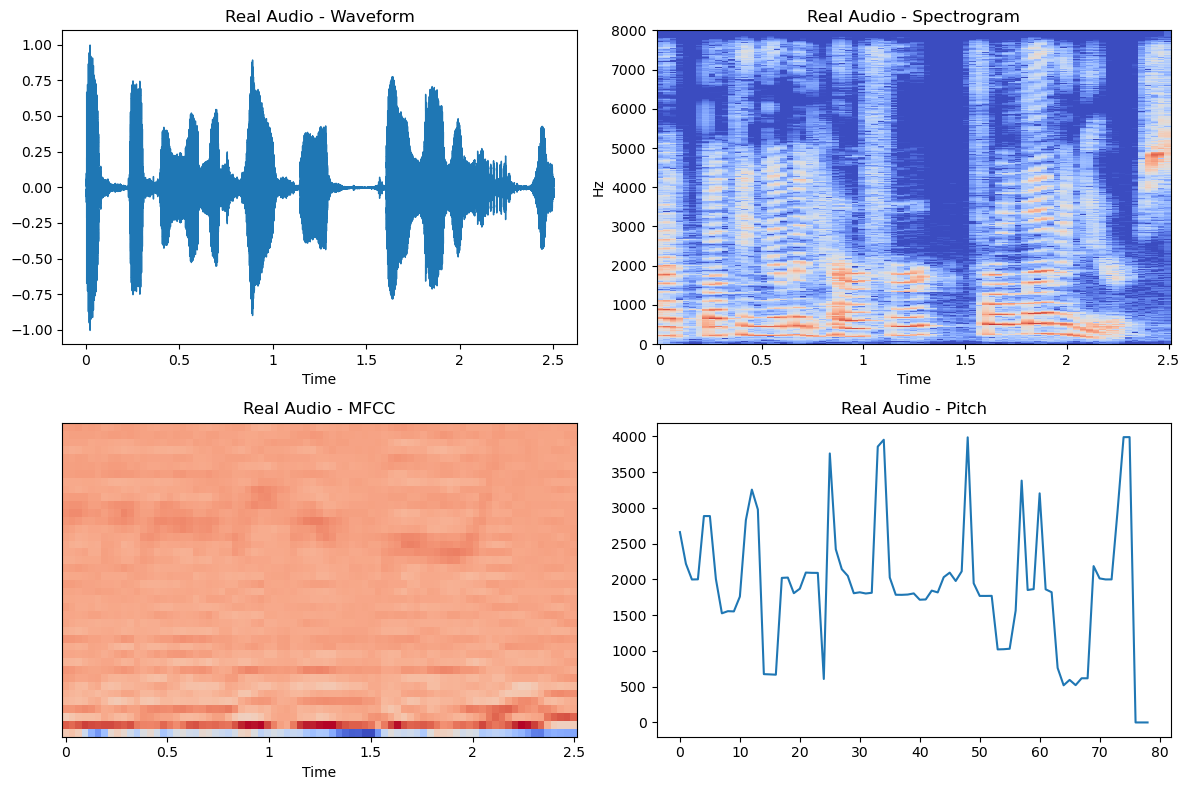

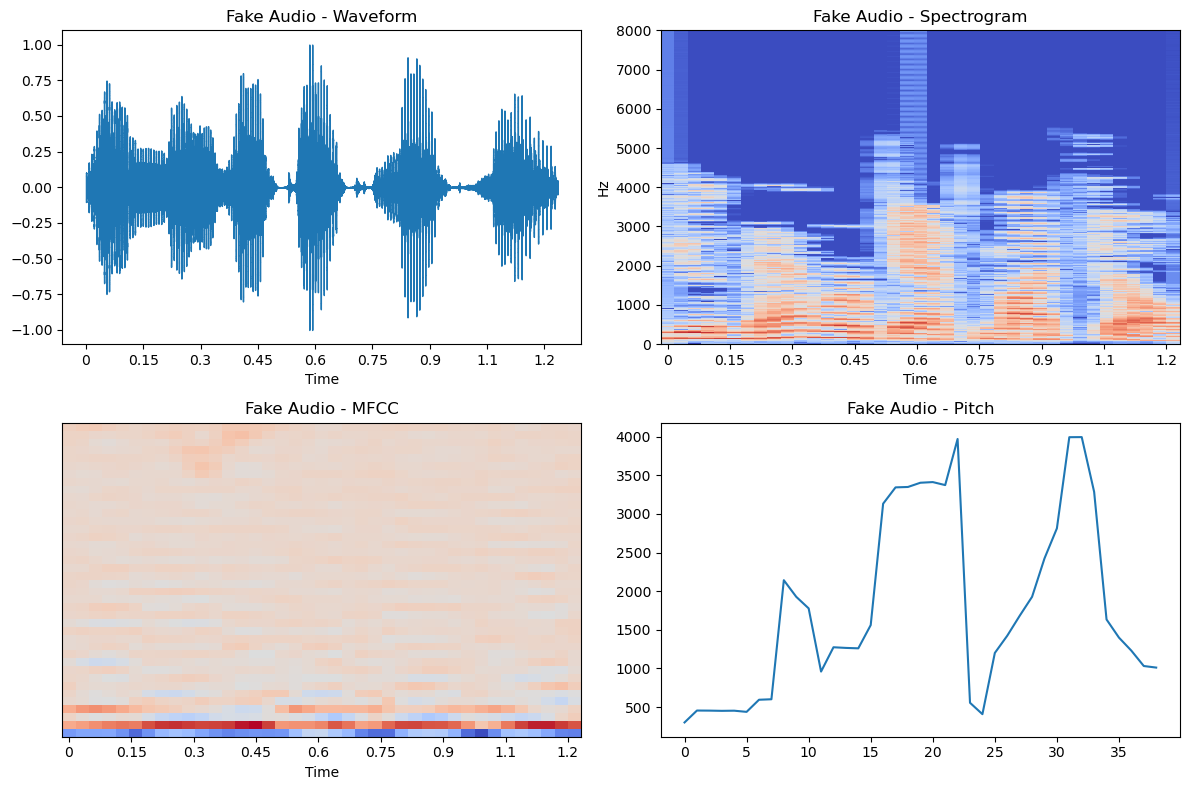

In [35]:
import librosa.display
import matplotlib.pyplot as plt
real_sample = [x for x,y in zip(X_train, y_train_raw) if y == 0][0]
fake_sample = [x for x,y in zip(X_train, y_train_raw) if y == 1][0]

def visualize_audio(file_path, title):
    audio, sr = librosa.load(file_path, sr=16000)

    plt.figure(figsize=(12,8))
    plt.subplot(2,2,1)
    librosa.display.waveshow(audio, sr=sr)
    plt.title(f"{title} - Waveform")

    # Spectrogram
    plt.subplot(2,2,2)
    spec = librosa.amplitude_to_db(abs(librosa.stft(audio)))
    librosa.display.specshow(spec, sr=sr, x_axis='time', y_axis='hz')
    plt.title(f"{title} - Spectrogram")

    # MFCC
    plt.subplot(2,2,3)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time')
    plt.title(f"{title} - MFCC")

    # Pitch
    plt.subplot(2,2,4)
    pitch, mag = librosa.piptrack(y=audio, sr=sr)
    pitch_vals = [pitch[:,i].max() for i in range(pitch.shape[1])]
    plt.plot(pitch_vals)
    plt.title(f"{title} - Pitch")

    plt.tight_layout()
    plt.show()

# Visualize
visualize_audio(real_sample, "Real Audio")
visualize_audio(fake_sample, "Fake Audio")

In [15]:
X_train_feat = np.load("X_train.npy")
y_train      = np.load("y_train.npy")

X_val_feat   = np.load("X_val.npy")
y_val        = np.load("y_val.npy")

X_test_feat  = np.load("X_test.npy")
y_test       = np.load("y_test.npy")

print(X_train_feat.shape)

(53866, 40, 174, 1)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

model = Sequential()

# 🔹 Block 1
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(40,174,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# 🔹 Block 2
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# 🔹 Block 3
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(GlobalAveragePooling2D())

# 🔹 Dense
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.6))

# 🔹 Output
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)             │ (None, 38, 172, 16)   │          160 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_5         │ (None, 38, 172, 16)   │           64 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_6               │ (None, 19, 86, 16)    │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_7 (Conv2D)             │ (None, 17, 84, 32)    │        4,640 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_6         │ (None, 17, 84, 32)    │          128 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_7               │ (None, 8, 42, 32)     │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_8 (Conv2D)             │ (None, 6, 40, 64)     │       18,496 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_8               │ (None, 3, 20, 64)     │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ global_average_pooling2d_1    │ (None, 64)            │            0 │
│ (GlobalAveragePooling2D)      │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_5 (Dense)               │ (None, 64)            │        4,160 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_3 (Dropout)           │ (None, 64)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_6 (Dense)               │ (None, 1)             │           65 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 27,713 (108.25 KB)

 Trainable params: 27,617 (107.88 KB)

 Non-trainable params: 96 (384.00 B)

In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [25]:
history = model.fit(
    X_train_feat,
    y_train,
    epochs=5,                 
    batch_size=32,
    validation_data=(X_val_feat, y_val),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 218s 127ms/step - accuracy: 0.9442 - loss: 0.1506 - val_accuracy: 0.9843 - val_loss: 0.0463
Epoch 2/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 199s 118ms/step - accuracy: 0.9816 - loss: 0.0552 - val_accuracy: 0.9753 - val_loss: 0.0681
Epoch 3/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 196s 116ms/step - accuracy: 0.9871 - loss: 0.0413 - val_accuracy: 0.9847 - val_loss: 0.0404
Epoch 4/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 194s 115ms/step - accuracy: 0.9887 - loss: 0.0373 - val_accuracy: 0.9899 - val_loss: 0.0279
Epoch 5/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 193s 115ms/step - accuracy: 0.9909 - loss: 0.0276 - val_accuracy: 0.9919 - val_loss: 0.0256


In [26]:
test_loss, test_acc = model.evaluate(X_test_feat, y_test)

print("\nFinal Results:")
print("Train Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Test Accuracy:", test_acc)

145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9458 - loss: 0.1428

Final Results:
Train Accuracy: 0.9909219145774841
Validation Accuracy: 0.9918503165245056
Test Accuracy: 0.9458351135253906


In [36]:
model.save("deepfake_voice_model_cnn.keras")

In [27]:
y_pred = (model.predict(X_test_feat) > 0.5).astype("int32")

145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


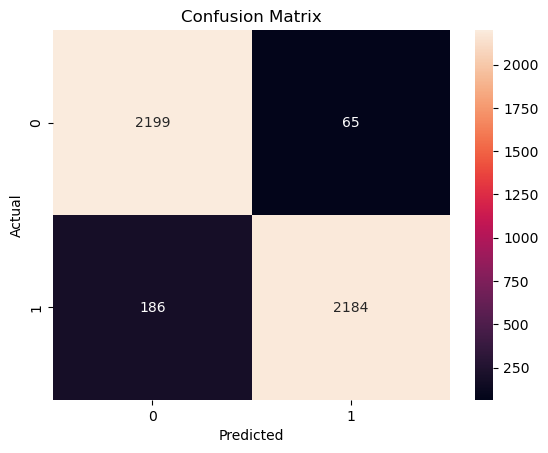

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred = (model.predict(X_test_feat) > 0.5).astype("int32")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision (for fake class = 1)
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("Performance Metrics:\n")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")

145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
Performance Metrics:

Accuracy  : 94.58%
Precision : 97.11%
Recall    : 92.15%
F1 Score  : 94.57%
